In [6]:
import pandas as pd
df_train= pd.read_csv("./data/raw/df_train.csv")
df_test=pd.read_csv("./data/raw/df_test.csv")

In [7]:
print("display train DataFrame columns")
display(df_train.columns)
print("display  test  DataFrame columns")
display(df_test.columns)

display train DataFrame columns


Index(['text', 'label', 'label_text'], dtype='object')

display  test  DataFrame columns


Index(['text', 'label', 'label_text'], dtype='object')

In [8]:
print("display train DataFrame shapes")
display(df_train.shape)

print("display  test  DataFrame shapes")

display(df_test.shape)


display train DataFrame shapes


(120000, 3)

display  test  DataFrame shapes


(7600, 3)

In [9]:
print("\n display train DataFrame infos \n ")

df_train.info()

print("\n display  test  DataFrame onfos \n")

df_test.info()


 display train DataFrame infos 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        120000 non-null  object
 1   label       120000 non-null  int64 
 2   label_text  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB

 display  test  DataFrame onfos 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        7600 non-null   object
 1   label       7600 non-null   int64 
 2   label_text  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


In [10]:
print("Display train DataFrame null values")
print(df_train.isna().sum(),"\n")
print("Display  test  DataFrame null values ")

print(df_test.isna().sum())

Display train DataFrame null values
text          0
label         0
label_text    0
dtype: int64 

Display  test  DataFrame null values 
text          0
label         0
label_text    0
dtype: int64


In [11]:
print("Duplicated values in the train DataFrame:")
print(df_train.duplicated().sum(), "\n")

print("Duplicated values in the test DataFrame:")
print(df_test.duplicated().sum())


Duplicated values in the train DataFrame:
0 

Duplicated values in the test DataFrame:
0


In [12]:
print("Unique values in the train label column:")
print(df_train["label"].unique(), "\n")

print("Unique values in the test label column:")
print(df_test["label"].unique())


Unique values in the train label column:
[2 3 1 0] 

Unique values in the test label column:
[2 3 1 0]


In [13]:
print("Label distribution in the train set:")
print(df_train["label"].value_counts(), "\n")

print("Label distribution in the test set:")
print(df_test["label"].value_counts())

Label distribution in the train set:
label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64 

Label distribution in the test set:
label
2    1900
3    1900
1    1900
0    1900
Name: count, dtype: int64


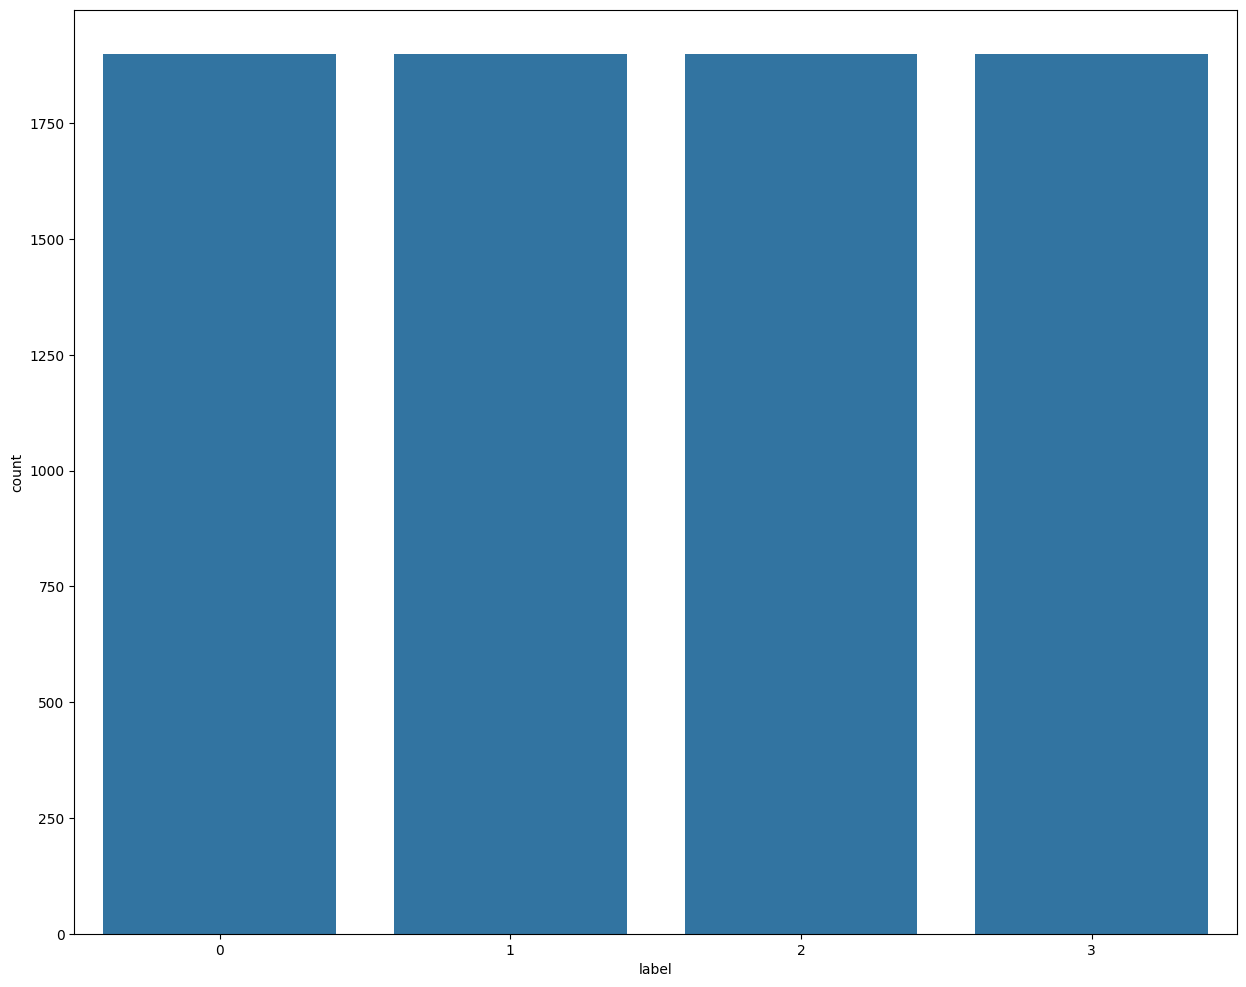

In [14]:
import seaborn as sns 
import matplotlib.pyplot as plt
plt.figure(figsize=(15,12))
sns.countplot(data=df_test,x="label")
plt.show()

In [15]:

print("describtion of text_length column")
df_train["text_length"]=df_train["text"].apply(lambda x : len(x.split()))
print(df_train["text_length"].describe())

print("describtion of text_length column")
df_test["text_length"]=df_test["text"].apply(lambda x : len(x.split()))
print(df_test["text_length"].describe())

describtion of text_length column
count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64
describtion of text_length column
count    7600.000000
mean       37.722368
std        10.129860
min        11.000000
25%        32.000000
50%        37.000000
75%        43.000000
max       137.000000
Name: text_length, dtype: float64


In [16]:
print(df_train["label_text"].unique())
print(df_train.columns)

['Business' 'Sci/Tech' 'Sports' 'World']
Index(['text', 'label', 'label_text', 'text_length'], dtype='object')


In [17]:
print(df_train["label_text"].value_counts())


label_text
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


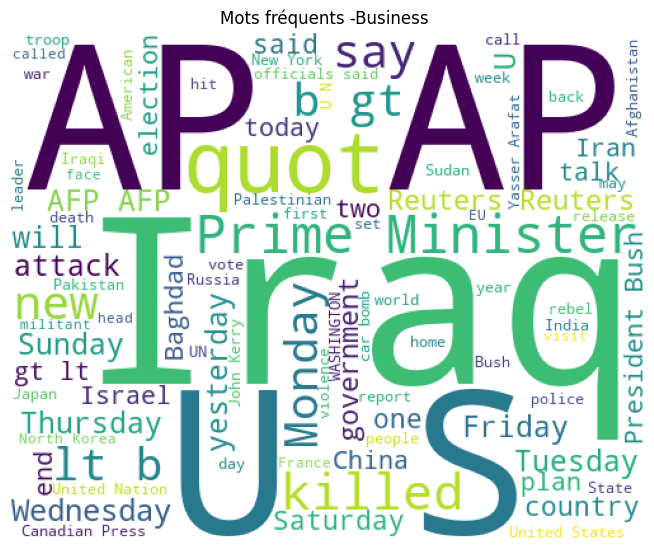

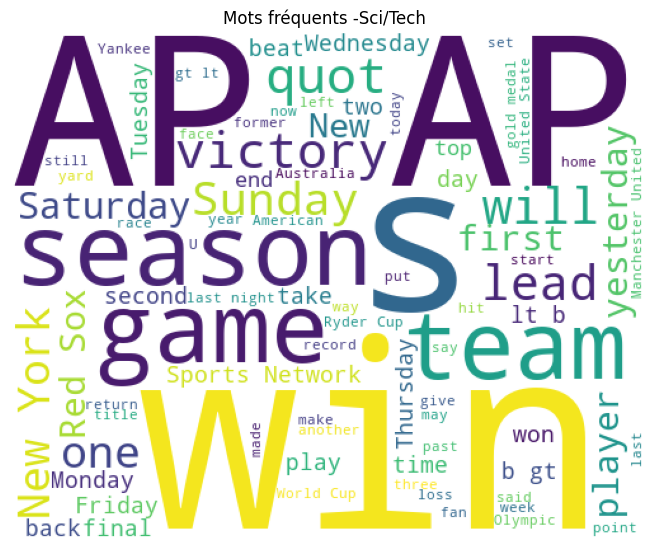

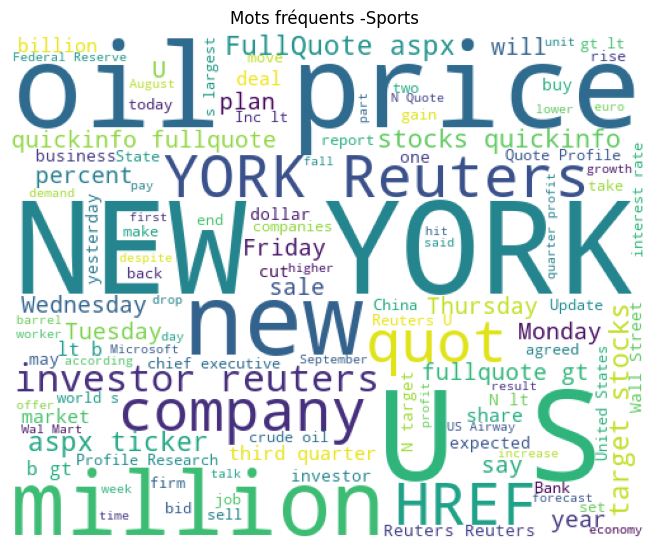

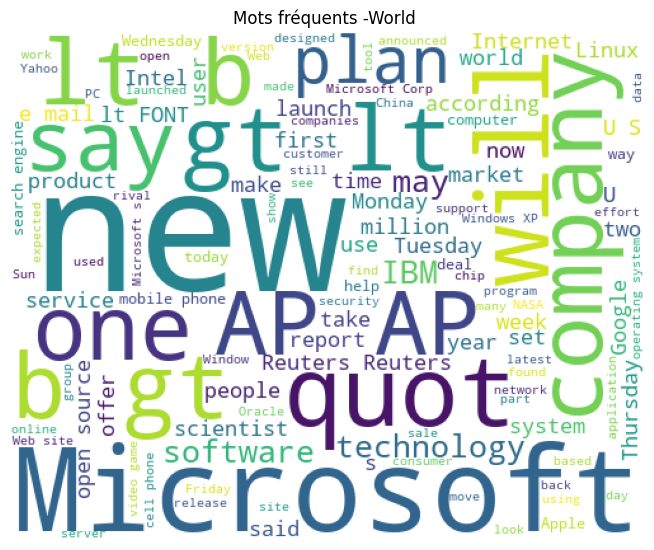

In [18]:
from wordcloud import WordCloud
wc=WordCloud(width=500 ,height=400,min_font_size=10,background_color="white")
labels=['Business', 'Sci/Tech' ,'Sports', 'World']

for i , label in enumerate(labels):
    wc_label=wc.generate(df_train[df_train["label"]==i]["text"].str.cat(sep=""))
    plt.figure(figsize=(18,12))
    plt.subplot(1,2,1)
    plt.imshow(wc_label)
    plt.title(f"Mots fréquents -{label} ")
    plt.axis('off')

In [ ]:
import re
df_train["text"]=df_train["text"].str.lower()
df_train["text"]=df_train["text"].str.replace(re.sub(r'[^a-zA-Z0-9\s]',' ',regex=True))
df_train["text"]=df_train["text"].str.replace(re.sub(r'^s+]',' ',regex=True))

df_train["text"]=df_train["text"].str.strip()


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))

def remove_stopwords(text):
    tokens=word_tokenize(text)
    unique_tokens=[w  for w in tokens if w not in stop_words]
    return ' '.join(unique_tokens)

df_train["text_clean"]=df_train['text'].apply(remove_stopwords)